In [1]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
sys.path.insert(0, os.path.abspath("."))

import pandas as pd
from cfb.fetch_data import fetch_lines_history

lines = fetch_lines_history([2021, 2022, 2023, 2024, 2025])
print(f"{len(lines)} provider-lines across {lines['game_id'].nunique()} games")
lines.head()

/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


17440 provider-lines across 6913 games


,game_id,season,week,home_team,away_team,provider,spread_close,spread_open,total_close,total_open
0,401310752,2021,13,Air Force,UNLV,teamrankings,-18.5,NaN,49.5,NaN
1,401310752,2021,13,Air Force,UNLV,consensus,-18.5,NaN,49.5,NaN
2,401310752,2021,13,Air Force,UNLV,William Hill (New Jersey),-18.5,NaN,49.5,NaN
3,401310752,2021,13,Air Force,UNLV,Bovada,-18.0,-18.0,49.5,49.5
4,401309910,2021,13,USC,BYU,teamrankings,8.5,NaN,65.5,NaN


In [2]:
# Which providers give us what we need? CLV requires BOTH an opener and a closer.
cov = lines.groupby(["provider", "season"]).agg(
    games=("game_id", "nunique"),
    has_close=("spread_close", lambda s: s.notna().sum()),
    has_open=("spread_open", lambda s: s.notna().sum()),
)
cov["both_pct"] = (100 * lines.dropna(subset=["spread_open", "spread_close"])
                   .groupby(["provider", "season"])["game_id"].nunique()
                   .reindex(cov.index).fillna(0) / cov["games"]).round(1)
cov

games  has_close  has_open  both_pct
provider                      season                                      
Bovada                        2021      879        878       878      99.9
                              2022      859        859       852      99.2
                              2023      854        854       852      99.8
                              2024      804        804       801      99.6
                              2025      934        934       934     100.0
Caesars (Pennsylvania)        2021       15         15         0       0.0
Caesars Sportsbook (Colorado) 2021        1          1         0       0.0
                              2022       33         33         0       0.0
                              2023       76         76         0       0.0
Draft Kings                   2025       64         64         0       0.0
DraftKings                    2023      757        754       753      99.5
                              2024      817        811       714      87.4
                              2025      805        805       683      84.8
ESPN Bet                      2023      469        469         0       0.0
                              2024     1551       1548       819      52.6
                              2025     1542       1532       878      56.4
William Hill (New Jersey)     2021      862        862         0       0.0
                              2022     1408       1408         0       0.0
                              2023      835        835         0       0.0
consensus                     2021      870        870         0       0.0
                              2022     1244       1244         0       0.0
                              2023       29         29         0       0.0
numberfire                    2021      145        145         0       0.0
teamrankings                  2021      769        769         0       0.0
                              2022      766        766         0       0.0
                              2023       52         52         0       0.0

In [3]:
# The consensus closer here should nearly match the spread_home already in games.parquet.
games = pd.read_parquet("data/raw/games.parquet").drop_duplicates(subset=["game_id"])
chk = lines[lines["provider"] == "consensus"].merge(
    games[["game_id", "spread_home"]], on="game_id", how="inner")
chk["diff"] = (chk["spread_close"] - chk["spread_home"]).abs()
print(f"{len(chk)} consensus games matched to v1 data")
print(f"median |spread_close - spread_home|: {chk['diff'].median()}")
print(f"games differing by > 1 point: {(chk['diff'] > 1).sum()}")

2062 consensus games matched to v1 data
median |spread_close - spread_home|: 0.0
games differing by > 1 point: 0


In [4]:
# Attach Bovada's opener and closer to the walk-forward predictions.
pf = pd.read_parquet("data/processed/pf_fbs.parquet")
bov = (lines[lines["provider"] == "Bovada"]
       .dropna(subset=["spread_open", "spread_close"])
       [["game_id", "spread_open", "spread_close"]]
       .rename(columns={"spread_close": "bov_close", "spread_open": "bov_open"}))

bf = pf.merge(bov, on="game_id", how="inner")
print(f"v1 predictions: {len(pf)}  |  with Bovada open+close: {len(bf)}")
print(f"line movement |close - open|: median {abs(bf['bov_close'] - bf['bov_open']).median()}, "
      f"moved at all: {(bf['bov_close'] != bf['bov_open']).mean():.1%}")
bf[["season","week","home_team","away_team","model_margin","margin","bov_open","bov_close"]].head()

v1 predictions: 2408  |  with Bovada open+close: 2396
line movement |close - open|: median 1.0, moved at all: 86.1%


,season,week,home_team,away_team,model_margin,margin,bov_open,bov_close
0,2022,4,Virginia Tech,West Virginia,3.578701,-23,3.0,2.5
1,2022,4,Georgia State,Coastal Carolina,-5.547195,-17,1.5,2.5
2,2022,4,Syracuse,Virginia,9.452584,2,-9.5,-10.0
3,2022,4,Air Force,Nevada,5.775152,28,-25.0,-24.0
4,2022,4,UTEP,Boise State,-13.968838,17,15.5,16.0


In [5]:
# Margin -> cover probability. P(home covers) needs the distribution of outcomes
# around the prediction, not just its center. sigma is estimated walk-forward:
# season S uses only residuals from out-of-sample predictions in seasons < S,
# so the probabilities obey the same no-future-information rule as the features.
from scipy import stats

bf["resid"] = bf["margin"] - bf["model_margin"]

sigmas = {}
for s in sorted(bf["season"].unique()):
    prior = bf.loc[bf["season"] < s, "resid"]
    sigmas[s] = prior.std() if len(prior) >= 200 else float("nan")
print("walk-forward sigma by season:", {k: round(v, 2) for k, v in sigmas.items()})

bf["sigma"] = bf["season"].map(sigmas)
eval_bf = bf.dropna(subset=["sigma"]).copy()   # drops the first season -- no prior residuals to learn sigma from

# Home covers when margin > -close. Model's probability of that, given its margin estimate:
eval_bf["p_cover"] = 1 - stats.norm.cdf((-eval_bf["bov_close"] - eval_bf["model_margin"]) / eval_bf["sigma"])
eval_bf["covered"] = (eval_bf["margin"] > -eval_bf["bov_close"]).astype(float)
push = eval_bf["margin"] == -eval_bf["bov_close"]
eval_bf = eval_bf[~push]   # pushes are neither side; drop them from scoring
print(f"\nscoring {len(eval_bf)} games ({push.sum()} pushes dropped)")
print(f"Brier score: {((eval_bf['p_cover'] - eval_bf['covered'])**2).mean():.4f}  (0.25 = coin flip; lower is better)")

walk-forward sigma by season: {np.int64(2022): nan, np.int64(2023): np.float64(16.23), np.int64(2024): np.float64(16.24), np.int64(2025): np.float64(16.2)}

scoring 1777 games (42 pushes dropped)
Brier score: 0.2661  (0.25 = coin flip; lower is better)


,games,p_mean,actual
p_bin,,,
"(0.0, 0.35]",261,0.275,0.452
"(0.35, 0.45]",392,0.407,0.526
"(0.45, 0.55]",539,0.498,0.514
"(0.55, 0.65]",378,0.594,0.513
"(0.65, 1.0]",207,0.713,0.473


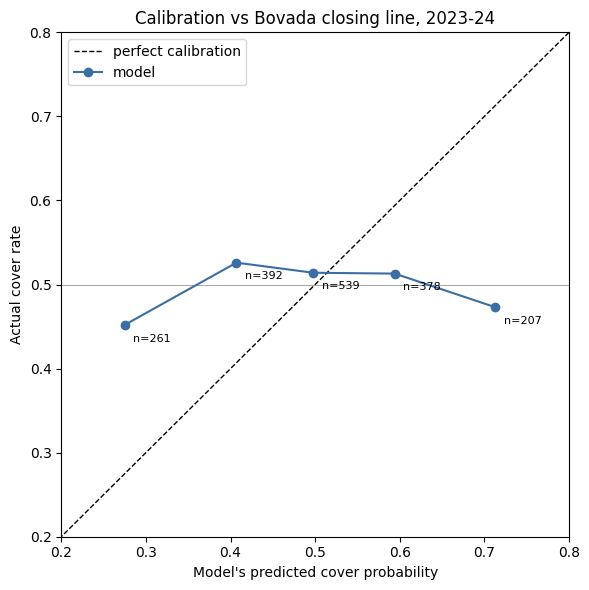

In [6]:
# Calibration: when the model says X%, how often does it happen?
# A flat line at 50% = no discrimination. A sloped-but-shallow line = signal, overconfident.
import numpy as np
import matplotlib.pyplot as plt

eval_bf["p_bin"] = pd.cut(eval_bf["p_cover"], bins=[0, .35, .45, .55, .65, 1.0])
cal = eval_bf.groupby("p_bin", observed=True).agg(
    games=("covered", "size"),
    p_mean=("p_cover", "mean"),
    actual=("covered", "mean"),
).round(3)
display(cal)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
ax.axhline(0.5, color="gray", lw=0.5)
ax.plot(cal["p_mean"], cal["actual"], "o-", color="#3b6ea5", label="model")
for _, r in cal.iterrows():
    ax.annotate(f"n={r['games']:.0f}", (r["p_mean"], r["actual"]),
                textcoords="offset points", xytext=(6, -12), fontsize=8)
ax.set_xlabel("Model's predicted cover probability")
ax.set_ylabel("Actual cover rate")
ax.set_xlim(0.2, 0.8); ax.set_ylim(0.2, 0.8)
ax.legend(); ax.set_title("Calibration vs Bovada closing line, 2023-24")
plt.tight_layout(); plt.show()

In [7]:
# Closing Line Value: bet against the OPENER where the model sees an edge,
# then measure whether the close moved toward the bet.
# Convention: spread is home-perspective, negative = home favored.
# Bet HOME -> you want the close MORE negative than the open -> clv = open - close.
# Bet AWAY -> you want the close LESS negative than the open -> clv = close - open.
eval_bf["p_cover_open"] = 1 - stats.norm.cdf((-eval_bf["bov_open"] - eval_bf["model_margin"]) / eval_bf["sigma"])

rows = []
for thresh in [0.55, 0.60, 0.65]:
    bets = eval_bf[(eval_bf["p_cover_open"] > thresh) | (eval_bf["p_cover_open"] < 1 - thresh)].copy()
    bets["side"] = np.where(bets["p_cover_open"] > 0.5, "home", "away")
    bets["clv"] = np.where(bets["side"] == "home",
                           bets["bov_open"] - bets["bov_close"],
                           bets["bov_close"] - bets["bov_open"])
    bets["won"] = np.where(bets["side"] == "home",
                           bets["margin"] > -bets["bov_close"],
                           bets["margin"] < -bets["bov_close"])
    rows.append({
        "threshold": thresh,
        "bets": len(bets),
        "mean_clv_pts": round(bets["clv"].mean(), 3),
        "pct_positive_clv": round((bets["clv"] > 0).mean() * 100, 1),
        "ats_win_pct": round(bets["won"].mean() * 100, 1),
    })
pd.DataFrame(rows)

,threshold,bets,mean_clv_pts,pct_positive_clv,ats_win_pct
0,0.55,1199,0.358,47.9,49.6
1,0.60,781,0.411,48.0,51.5
2,0.65,453,0.587,50.1,53.9


In [8]:
# Controls: is the positive CLV model skill, or structural line drift that any
# dumb strategy would collect? Compare against null strategies on ALL games.
ctl = eval_bf.copy()
ctl["clv_home"] = ctl["bov_open"] - ctl["bov_close"]   # strategy: always bet home
ctl["clv_fav"]  = np.where(ctl["bov_open"] < 0,
                           ctl["bov_open"] - ctl["bov_close"],   # favorite = home
                           ctl["bov_close"] - ctl["bov_open"])   # favorite = away
print(f"null CLV, always bet HOME:          {ctl['clv_home'].mean():+.3f} pts")
print(f"null CLV, always bet OPEN FAVORITE: {ctl['clv_fav'].mean():+.3f} pts")

# What is the model actually betting at the 0.65 threshold?
bets = eval_bf[(eval_bf["p_cover_open"] > 0.65) | (eval_bf["p_cover_open"] < 0.35)].copy()
bets["side"] = np.where(bets["p_cover_open"] > 0.5, "home", "away")
bets["fav_at_open"] = np.where(bets["bov_open"] < 0, "home", "away")
print(f"\nmodel's {len(bets)} bets: {bets['side'].value_counts().to_dict()}")
print(f"share of bets on the opener's favorite: {(bets['side'] == bets['fav_at_open']).mean():.1%}")

# And the statistical reality of the ATS record:
import math
n = len(bets)
se = math.sqrt(0.5 * 0.5 / n)
print(f"\nATS 54.5% on n={n}: 95% CI roughly ±{1.96*se:.1%} -- breakeven (52.4%) is inside it")

null CLV, always bet HOME:          -0.259 pts
null CLV, always bet OPEN FAVORITE: -0.195 pts

model's 453 bets: {'away': 267, 'home': 186}
share of bets on the opener's favorite: 24.1%

ATS 54.5% on n=453: 95% CI roughly ±4.6% -- breakeven (52.4%) is inside it


In [9]:
# Cleanest control: on the model's own selected games, compare its CLV to
# blindly betting the opener's underdog on those same games. The difference
# is the CLV attributable to the model's side-picking, holding selection fixed.
bets["clv"] = np.where(bets["side"] == "home",
                       bets["bov_open"] - bets["bov_close"],
                       bets["bov_close"] - bets["bov_open"])
bets["clv_dog"] = np.where(bets["fav_at_open"] == "home",
                           bets["bov_close"] - bets["bov_open"],   # dog = away
                           bets["bov_open"] - bets["bov_close"])   # dog = home
agree = (bets["side"] != bets["fav_at_open"]).mean()
print(f"model CLV on its 292 bets:            {bets['clv'].mean():+.3f} pts")
print(f"always-dog CLV on the SAME 292 games: {bets['clv_dog'].mean():+.3f} pts")
print(f"(model sides with the dog in {agree:.1%} of these games)")

model CLV on its 292 bets:            +0.587 pts
always-dog CLV on the SAME 292 games: +0.298 pts
(model sides with the dog in 75.9% of these games)


In [10]:
cols = ["game_id","season","week","home_team","away_team","model_margin","margin",
        "bov_open","bov_close","sigma","p_cover"]
eval_bf[cols].to_parquet("data/processed/demo_games.parquet")
print(f"saved {len(eval_bf)} games for the demo app")

saved 1777 games for the demo app


In [11]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
sys.path.insert(0, os.path.abspath("."))

from cfb.fetch_data import fetch_team_logos
logos = fetch_team_logos()
logos.to_parquet("data/processed/team_logos.parquet")
print(f"saved {len(logos)} team logos")

saved 759 team logos


In [12]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
sys.path.insert(0, os.path.abspath("."))
import pandas as pd
from cfb.fetch_data import fetch_schedule, fetch_talent
from sklearn.linear_model import Ridge

sched = fetch_schedule(2026, weeks=set(range(1, 17)))
print(f"{len(sched)} scheduled 2026 games, weeks 1-16")

tal26 = fetch_talent([2026])
if len(tal26):
    pf_full = pd.read_parquet("data/processed/pf_fbs.parquet")
    tr = pf_full.dropna(subset=["talent_diff", "home_field", "margin"])
    prior = Ridge(alpha=1.0).fit(tr[["talent_diff", "home_field"]], tr["margin"])
    tmap = dict(zip(tal26["team"], tal26["talent_z"]))
    tmin = tal26["talent_z"].min()
    sched["talent_h"] = sched["home_team"].map(tmap).fillna(tmin)
    sched["talent_a"] = sched["away_team"].map(tmap).fillna(tmin)
    sched["talent_diff"] = sched["talent_h"] - sched["talent_a"]
    sched["home_field"] = 1
    sched["prior_margin"] = prior.predict(sched[["talent_diff", "home_field"]])
    print("2026 talent found -> preseason prior attached")
else:
    print("no 2026 talent published yet -> schedule saved without prior")
sched.to_parquet("data/processed/schedule_2026.parquet")
print("saved data/processed/schedule_2026.parquet")

888 scheduled 2026 games, weeks 1-16
no 2026 talent published yet -> schedule saved without prior
saved data/processed/schedule_2026.parquet


In [13]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
sys.path.insert(0, os.path.abspath("."))
import pandas as pd
from cfb.fetch_data import fetch_schedule, fetch_talent, fetch_lines_history
from sklearn.linear_model import Ridge

sched = fetch_schedule(2026, weeks=set(range(1, 17)))   # fresh -- no spread column yet
print(f"{len(sched)} scheduled 2026 games, weeks 1-16")

lines26 = fetch_lines_history([2026])
pref = {"Bovada": 0, "DraftKings": 1, "ESPN Bet": 2, "consensus": 3}
best = (lines26.dropna(subset=["spread_close"])
        .assign(rank=lambda d: d["provider"].map(pref).fillna(9))
        .sort_values("rank").drop_duplicates("game_id")
        [["game_id", "provider", "spread_close", "home_team"]]
        .rename(columns={"spread_close": "spread", "provider": "spread_provider",
                         "home_team": "lines_home"}))
sched = sched.merge(best, on="game_id", how="left")
flip = sched["lines_home"].notna() & (sched["lines_home"] != sched["home_team"])
sched.loc[flip, "spread"] = -sched.loc[flip, "spread"]
print(f"{sched['spread'].notna().sum()} of {len(sched)} games have a posted spread; "
      f"{flip.sum()} aligned for home-team disagreement (neutral sites)")
sched = sched.drop(columns=["lines_home"])
# MANUAL OVERRIDE: 2026 Wk1 Notre Dame vs Wisconsin (Lambeau, neutral).
# CFBD/Bovada entry has the sign flipped vs the actual market (ND -20.5,
# confirmed vs ESPN 2026-07-09). Remove once the source corrects itself.
nd_fix = ((sched["week"] == 1) & (sched["home_team"] == "Notre Dame")
          & (sched["away_team"] == "Wisconsin") & (sched["spread"] > 0))
sched.loc[nd_fix, "spread"] = -sched.loc[nd_fix, "spread"]
if nd_fix.any():
    print("applied ND-Wisconsin sign override")
tal26 = fetch_talent([2026])
if len(tal26):
    pf_full = pd.read_parquet("data/processed/pf_fbs.parquet")
    tr = pf_full.dropna(subset=["talent_diff", "home_field", "margin"])
    prior = Ridge(alpha=1.0).fit(tr[["talent_diff", "home_field"]], tr["margin"])
    tmap = dict(zip(tal26["team"], tal26["talent_z"]))
    tmin = tal26["talent_z"].min()
    sched["talent_h"] = sched["home_team"].map(tmap).fillna(tmin)
    sched["talent_a"] = sched["away_team"].map(tmap).fillna(tmin)
    sched["talent_diff"] = sched["talent_h"] - sched["talent_a"]
    sched["home_field"] = 1
    sched["prior_margin"] = prior.predict(sched[["talent_diff", "home_field"]])
    print("2026 talent found -> preseason prior attached")
else:
    print("no 2026 talent published yet -> no prior")
sched.to_parquet("data/processed/schedule_2026.parquet")
print("saved data/processed/schedule_2026.parquet")

888 scheduled 2026 games, weeks 1-16
53 of 888 games have a posted spread; 0 aligned for home-team disagreement (neutral sites)
applied ND-Wisconsin sign override
no 2026 talent published yet -> no prior
saved data/processed/schedule_2026.parquet


In [14]:
sched = pd.read_parquet("data/processed/schedule_2026.parquet")
nd = sched[(sched["home_team"] == "Notre Dame") | (sched["away_team"] == "Notre Dame")]
print(nd[["week", "home_team", "away_team", "spread", "spread_provider"]].head(10))

     week       home_team       away_team  spread spread_provider
97      1      Notre Dame       Wisconsin   -20.5          Bovada
131     2      Notre Dame            Rice     NaN            None
245     3      Notre Dame  Michigan State     NaN            None
267     4          Purdue      Notre Dame     NaN            None
366     5  North Carolina      Notre Dame     NaN            None
443     6      Notre Dame        Stanford     NaN            None
478     7             BYU      Notre Dame     NaN            None
612     9            Navy      Notre Dame     NaN            None
680    10      Notre Dame           Miami     NaN            None
744    11      Notre Dame  Boston College     NaN            None


In [15]:
import sys, os
os.chdir(os.path.expanduser("~/Downloads/cfb-spread-model"))
sys.path.insert(0, os.path.abspath("."))
import pandas as pd
from cfb.fetch_data import fetch_schedule, fetch_talent, fetch_lines_market
from sklearn.linear_model import Ridge

sched = fetch_schedule(2026, weeks=set(range(1, 17)))
print(f"{len(sched)} scheduled 2026 games, weeks 1-16")

mkt = fetch_lines_market([2026])
pref = {"Bovada": 0, "DraftKings": 1, "ESPN Bet": 2, "consensus": 3}
best = (mkt.dropna(subset=["spread"])
        .assign(rank=lambda d: d["provider"].map(pref).fillna(9))
        .sort_values("rank").drop_duplicates("game_id")
        [["game_id", "provider", "lines_home", "spread", "total", "ml_home", "ml_away"]]
        .rename(columns={"provider": "spread_provider"}))
sched = sched.merge(best, on="game_id", how="left")

# align spread sign where the lines feed disagrees on the home team (neutral sites)
flip = sched["lines_home"].notna() & (sched["lines_home"] != sched["home_team"])
sched.loc[flip, "spread"] = -sched.loc[flip, "spread"]
if flip.any():
    ml_h = sched.loc[flip, "ml_home"].copy()
    sched.loc[flip, "ml_home"] = sched.loc[flip, "ml_away"]
    sched.loc[flip, "ml_away"] = ml_h
sched = sched.drop(columns=["lines_home"])

# MANUAL OVERRIDE: 2026 Wk1 ND-Wisconsin (Lambeau) -- source sign flipped vs
# actual market (ND -20.5, confirmed vs ESPN 2026-07-09). Self-disarming.
nd_fix = ((sched["week"] == 1) & (sched["home_team"] == "Notre Dame")
          & (sched["away_team"] == "Wisconsin") & (sched["spread"] > 0))
sched.loc[nd_fix, "spread"] = -sched.loc[nd_fix, "spread"]
if nd_fix.any():
    print("applied ND-Wisconsin sign override")
    ml_h = sched.loc[nd_fix, "ml_home"].copy()
    sched.loc[nd_fix, "ml_home"] = sched.loc[nd_fix, "ml_away"]
    sched.loc[nd_fix, "ml_away"] = ml_h

print(f"posted: {sched['spread'].notna().sum()} spreads, "
      f"{sched['total'].notna().sum()} totals, "
      f"{sched['ml_home'].notna().sum()} moneylines; {flip.sum()} home-team alignments")

tal26 = fetch_talent([2026])
if len(tal26):
    pf_full = pd.read_parquet("data/processed/pf_fbs.parquet")
    tr = pf_full.dropna(subset=["talent_diff", "home_field", "margin"])
    prior = Ridge(alpha=1.0).fit(tr[["talent_diff", "home_field"]], tr["margin"])
    tmap = dict(zip(tal26["team"], tal26["talent_z"]))
    tmin = tal26["talent_z"].min()
    sched["talent_h"] = sched["home_team"].map(tmap).fillna(tmin)
    sched["talent_a"] = sched["away_team"].map(tmap).fillna(tmin)
    sched["talent_diff"] = sched["talent_h"] - sched["talent_a"]
    sched["home_field"] = 1
    sched["prior_margin"] = prior.predict(sched[["talent_diff", "home_field"]])
    print("2026 talent found -> preseason prior attached")
else:
    print("no 2026 talent published yet -> no prior")
sched.to_parquet("data/processed/schedule_2026.parquet")
print("saved data/processed/schedule_2026.parquet")

888 scheduled 2026 games, weeks 1-16
applied ND-Wisconsin sign override
posted: 53 spreads, 51 totals, 37 moneylines; 0 home-team alignments
no 2026 talent published yet -> no prior
saved data/processed/schedule_2026.parquet


In [16]:
import os
sched = pd.read_parquet("data/processed/schedule_2026.parquet")
early = sched[sched["week"] <= 3][["game_id", "week", "home_team", "away_team", "start_date"]].copy()
early["my_spread"] = ""   # home perspective: negative = home favored, e.g. -6.5
early["posted_date"] = ""
os.makedirs("my_lines", exist_ok=True)
early.sort_values(["week", "start_date"]).to_csv("my_lines/2026_weeks1-3.csv", index=False)
print(f"template: {len(early)} games -> my_lines/2026_weeks1-3.csv")

template: 260 games -> my_lines/2026_weeks1-3.csv


In [17]:
# Tiki's manual lines for weeks 1-3 (Track B: forward-looking only, graded later)
try:
    mine = pd.read_csv("my_lines/2026_weeks1-3.csv")
    mine = mine[pd.to_numeric(mine["my_spread"], errors="coerce").notna()]
    mine["my_spread"] = mine["my_spread"].astype(float)
    sched = sched.merge(mine[["game_id", "my_spread"]], on="game_id", how="left")
    print(f"Tiki's lines: {sched['my_spread'].notna().sum()} games")
except FileNotFoundError:
    pass

Tiki's lines: 0 games
